# Huấn luyện Mô hình Transformer Dự đoán Giá Nhà
Notebook này thực hiện huấn luyện mô hình Transformer cho dữ liệu bảng để dự đoán giá nhà tại Việt Nam. Nó tái hiện lại toàn bộ luồng xử lý từ file `train_transformer.py` nhưng hiển thị trực quan các kết quả, biểu đồ ngay trong môi trường Jupyter Notebook.

In [1]:
import os
import sys
import json
import pickle
import random
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from IPython.display import display, HTML
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Hiển thị đầy đủ nội dung bảng, không rút gọn bằng dấu "...".
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)
pd.set_option("display.expand_frame_repr", False)

# Giảm log rác từ Jupyter/VS Code để output chỉ còn thông tin của mô hình.
warnings.filterwarnings("ignore")
for logger_name in ["tornado", "tornado.general", "zmq", "ipykernel"]:
    logging.getLogger(logger_name).setLevel(logging.CRITICAL)
logging.getLogger("tornado.general").disabled = True

# CSS giúp bảng trong notebook xuống dòng đầy đủ thay vì cắt bằng dấu ba chấm.
display(HTML("""
<style>
.output_area table.dataframe {
    width: 100% !important;
    table-layout: auto !important;
}
.output_area table.dataframe th,
.output_area table.dataframe td {
    white-space: pre-wrap !important;
    word-break: break-word !important;
    text-align: left !important;
    vertical-align: top !important;
    max-width: none !important;
}
</style>
"""))


def print_section(title: str) -> None:
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)


def display_full_table(df: pd.DataFrame) -> None:
    """Hiển thị bảng với nội dung đầy đủ, không ẩn bớt text dài."""
    display(df.style.set_properties(**{
        "white-space": "pre-wrap",
        "text-align": "left",
        "vertical-align": "top",
    }).set_table_styles([
        {"selector": "th", "props": [("text-align", "left"), ("white-space", "pre-wrap")]},
        {"selector": "td", "props": [("max-width", "900px")]},
    ]))

# Thiết lập đường dẫn tới thư mục dự án
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "transformer":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
    TRANSFORMER_DIR = NOTEBOOK_DIR
else:
    PROJECT_ROOT = NOTEBOOK_DIR
    TRANSFORMER_DIR = NOTEBOOK_DIR / "transformer"

# Thêm thư mục transformer vào sys.path để có thể import transformer_model
if str(TRANSFORMER_DIR) not in sys.path:
    sys.path.append(str(TRANSFORMER_DIR))

from transformer_model import HousePriceTransformer

OUTPUT_DIR = TRANSFORMER_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print_section("0. KIỂM TRA ĐƯỜNG DẪN ĐANG CHẠY")
print(f"Project root     : {PROJECT_ROOT}")
print(f"Transformer dir  : {TRANSFORMER_DIR}")
print(f"Output dir       : {OUTPUT_DIR}")
print("\nCác file model, biểu đồ và metric sau khi train sẽ được lưu trong Output dir ở trên.")



0. KIỂM TRA ĐƯỜNG DẪN ĐANG CHẠY
Project root     : /Users/tangoctai/Downloads/NHÓM 1 - HỆ THỐNG WEB DỰ ĐOÁN GIÁ NHÀ VIỆT NAM SỬ DỤNG MÔ HÌNH MACHINE LEARNING - 6,7 ĐIỂM/dự đoán giá nhà
Transformer dir  : /Users/tangoctai/Downloads/NHÓM 1 - HỆ THỐNG WEB DỰ ĐOÁN GIÁ NHÀ VIỆT NAM SỬ DỤNG MÔ HÌNH MACHINE LEARNING - 6,7 ĐIỂM/dự đoán giá nhà/transformer
Output dir       : /Users/tangoctai/Downloads/NHÓM 1 - HỆ THỐNG WEB DỰ ĐOÁN GIÁ NHÀ VIỆT NAM SỬ DỤNG MÔ HÌNH MACHINE LEARNING - 6,7 ĐIỂM/dự đoán giá nhà/transformer/outputs

Các file model, biểu đồ và metric sau khi train sẽ được lưu trong Output dir ở trên.


In [2]:
# Thiết lập seed để kết quả ổn định và có thể tái lập
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
        
set_seed(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Thiết bị sử dụng: {device}")

Thiết bị sử dụng: mps


## 1. Tải và Làm sạch Dữ liệu
Chúng ta sẽ gộp dữ liệu chung cư và nhà đất, sau đó thực hiện lọc bỏ các giá trị bất thường (outliers) tương tự như trong file script `.py`.

In [3]:
# Ánh xạ Quận/Huyện về Tỉnh/Thành phố tương ứng
DISTRICT_TO_PROVINCE = {
    # Hà Nội
    "Cầu Giấy": "Hà Nội", "Nam Từ Liêm": "Hà Nội", "Bắc Từ Liêm": "Hà Nội", 
    "Tây Hồ": "Hà Nội", "Thanh Xuân": "Hà Nội", "Hà Đông": "Hà Nội", 
    "Đống Đa": "Hà Nội", "Hoàng Mai": "Hà Nội", "Long Biên": "Hà Nội", 
    "Ba Đình": "Hà Nội", "Hai Bà Trưng": "Hà Nội", "Gia Lâm": "Hà Nội", 
    "Đông Anh": "Hà Nội", "Thanh Trì": "Hà Nội", "Hoài Đức": "Hà Nội",
    
    # TP. Hồ Chí Minh
    "Quận 1": "TP. Hồ Chí Minh", "Quận 2": "TP. Hồ Chí Minh", "Quận 3": "TP. Hồ Chí Minh", 
    "Quận 4": "TP. Hồ Chí Minh", "Quận 5": "TP. Hồ Chí Minh", "Quận 6": "TP. Hồ Chí Minh", 
    "Quận 7": "TP. Hồ Chí Minh", "Quận 8": "TP. Hồ Chí Minh", "Quận 9": "TP. Hồ Chí Minh", 
    "Quận 10": "TP. Hồ Chí Minh", "Quận 11": "TP. Hồ Chí Minh", "Quận 12": "TP. Hồ Chí Minh", 
    "Bình Tân": "TP. Hồ Chí Minh", "Bình Thạnh": "TP. Hồ Chí Minh", "Tân Phú": "TP. Hồ Chí Minh", 
    "Bình Chánh": "TP. Hồ Chí Minh", "Thủ Đức": "TP. Hồ Chí Minh", "Tân Bình": "TP. Hồ Chí Minh", 
    "Phú Nhuận": "TP. Hồ Chí Minh", "Nhà Bè": "TP. Hồ Chí Minh", "Hóc Môn": "TP. Hồ Chí Minh", 
    "Gò Vấp": "TP. Hồ Chí Minh",
    
    # Đà Nẵng
    "Ngũ Hành Sơn": "Đà Nẵng", "Sơn Trà": "Đà Nẵng", "Cẩm Lệ": "Đà Nẵng", 
    "Liên Chiểu": "Đà Nẵng", "Hải Châu": "Đà Nẵng"
}

FEATURES = [
    "area_m2",          # diện tích
    "bedrooms_num",     # số phòng ngủ
    "district",         # quận
    "tinh_thanh",       # tỉnh/thành phố
    "direction",        # hướng
    "furniture_std",    # nội thất
    "legal_std",        # pháp lý
    "floors_num",       # số tầng
    "frontage_m",       # mặt tiền
    "road_width_m",     # đường rộng
    "loai_bds",         # loại bất động sản
]
TARGET = "price_billion" # Giá nhà (tỷ VNĐ)
NUMERIC_FEATURES = ["area_m2", "bedrooms_num", "floors_num", "frontage_m", "road_width_m"]
CATEGORICAL_FEATURES = ["district", "tinh_thanh", "direction", "furniture_std", "legal_std", "loai_bds"]


def load_clean_data() -> pd.DataFrame:
    cc_path = PROJECT_ROOT / "data" / "processed" / "cleaned_chung_cu.csv"
    nd_path = PROJECT_ROOT / "data" / "processed" / "cleaned_nha_dat.csv"
    df_cc = pd.read_csv(cc_path)
    df_nd = pd.read_csv(nd_path)

    print_section("1. ĐỌC VÀ LÀM SẠCH DỮ LIỆU")
    print(f"File chung cư : {cc_path}")
    print(f"File nhà đất  : {nd_path}")
    print(f"Số dòng chung cư ban đầu : {len(df_cc):,}")
    print(f"Số dòng nhà đất ban đầu  : {len(df_nd):,}")

    df_cc["loai_bds"] = "chung_cu"
    df_nd["loai_bds"] = "nha_dat"
    if "balcony_direction" in df_cc.columns:
        df_cc = df_cc.drop(columns=["balcony_direction"])

    for col in ["floors_num", "frontage_m", "road_width_m"]:
        df_cc[col] = 0
 
    df_cc["tinh_thanh"] = df_cc["district"].map(DISTRICT_TO_PROVINCE).fillna("Khác")
    df_nd["tinh_thanh"] = df_nd["district"].map(DISTRICT_TO_PROVINCE).fillna("Khác")

    all_cols = [TARGET] + FEATURES
    df = pd.concat([df_cc[all_cols], df_nd[all_cols]], ignore_index=True)
    before_clean = len(df)

    df = df.dropna(subset=[TARGET, "area_m2"])
    after_dropna = len(df)
    df = df[(df[TARGET] >= 1) & (df[TARGET] <= 200)] 
    after_price_filter = len(df)
    df = df[(df["area_m2"] >= 10) & (df["area_m2"] <= 1000)] 
    after_area_filter = len(df)

    for col in NUMERIC_FEATURES:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
    for col in CATEGORICAL_FEATURES:
        df[col] = df[col].fillna("Không rõ").astype(str)

    print(f"Tổng số dòng sau khi gộp             : {before_clean:,}")
    print(f"Sau khi bỏ dòng thiếu giá/diện tích  : {after_dropna:,}")
    print(f"Sau khi lọc giá từ 1 đến 200 tỷ      : {after_price_filter:,}")
    print(f"Sau khi lọc diện tích 10-1000 m2     : {after_area_filter:,}")
    print(f"Số dòng cuối cùng dùng để train      : {after_area_filter:,}")
    return df.reset_index(drop=True)


df = load_clean_data()

print("\nCác cột đầu vào được dùng:")
for i, col in enumerate(FEATURES, start=1):
    kind = "số" if col in NUMERIC_FEATURES else "phân loại/chữ"
    print(f"  {i:02d}. {col} ({kind})")
print(f"\nCột cần dự đoán: {TARGET} (giá nhà, đơn vị tỷ VNĐ)")

print("\n5 dòng dữ liệu đầu tiên sau khi làm sạch:")
display_full_table(df.head())



1. ĐỌC VÀ LÀM SẠCH DỮ LIỆU
File chung cư : /Users/tangoctai/Downloads/NHÓM 1 - HỆ THỐNG WEB DỰ ĐOÁN GIÁ NHÀ VIỆT NAM SỬ DỤNG MÔ HÌNH MACHINE LEARNING - 6,7 ĐIỂM/dự đoán giá nhà/data/processed/cleaned_chung_cu.csv
File nhà đất  : /Users/tangoctai/Downloads/NHÓM 1 - HỆ THỐNG WEB DỰ ĐOÁN GIÁ NHÀ VIỆT NAM SỬ DỤNG MÔ HÌNH MACHINE LEARNING - 6,7 ĐIỂM/dự đoán giá nhà/data/processed/cleaned_nha_dat.csv
Số dòng chung cư ban đầu : 5,452
Số dòng nhà đất ban đầu  : 6,379
Tổng số dòng sau khi gộp             : 11,831
Sau khi bỏ dòng thiếu giá/diện tích  : 11,831
Sau khi lọc giá từ 1 đến 200 tỷ      : 11,786
Sau khi lọc diện tích 10-1000 m2     : 11,786
Số dòng cuối cùng dùng để train      : 11,786

Các cột đầu vào được dùng:
  01. area_m2 (số)
  02. bedrooms_num (số)
  03. district (phân loại/chữ)
  04. tinh_thanh (phân loại/chữ)
  05. direction (phân loại/chữ)
  06. furniture_std (phân loại/chữ)
  07. legal_std (phân loại/chữ)
  08. floors_num (số)


,price_billion,area_m2,bedrooms_num,district,tinh_thanh,direction,furniture_std,legal_std,floors_num,frontage_m,road_width_m,loai_bds
0,6.400000,75.000000,2.000000,Hoài Đức,Hà Nội,Không rõ,Cơ bản,HĐMB,0.000000,0.000000,0.000000,chung_cu
1,19.200000,118.200000,3.000000,Tây Hồ,Hà Nội,Đông - Nam,Cơ bản,HĐMB,0.000000,0.000000,0.000000,chung_cu
2,7.550000,75.000000,2.000000,Hoàng Mai,Hà Nội,Đông - Nam,Đầy đủ,Sổ đỏ/Sổ hồng,0.000000,0.000000,0.000000,chung_cu
3,9.200000,99.100000,3.000000,Tây Hồ,Hà Nội,Không rõ,Đầy đủ,Sổ đỏ/Sổ hồng,0.000000,0.000000,0.000000,chung_cu
4,9.300000,97.500000,3.000000,Bắc Từ Liêm,Hà Nội,Đông - Nam,Đầy đủ,Sổ đỏ/Sổ hồng,0.000000,0.000000,0.000000,chung_cu


## 2. Phân chia dữ liệu Train / Validation / Test
Chia tập dữ liệu theo tỷ lệ 70% Train, 15% Validation, và 15% Test.

In [4]:
train_val_df, test_df = train_test_split(df, test_size=0.15, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.1765, random_state=42)

print_section("2. CHIA DỮ LIỆU TRAIN / VALIDATION / TEST")
print(f"Tổng dữ liệu sau làm sạch : {len(df):,} mẫu")
print(f"Train      : {len(train_df):,} mẫu, dùng để mô hình học")
print(f"Validation : {len(val_df):,} mẫu, dùng để chọn epoch/mô hình tốt nhất")
print(f"Test       : {len(test_df):,} mẫu, chỉ dùng để chấm điểm cuối cùng")
print("\nTỷ lệ xấp xỉ: Train 70%, Validation 15%, Test 15%")



2. CHIA DỮ LIỆU TRAIN / VALIDATION / TEST
Tổng dữ liệu sau làm sạch : 11,786 mẫu
Train      : 8,249 mẫu, dùng để mô hình học
Validation : 1,769 mẫu, dùng để chọn epoch/mô hình tốt nhất
Test       : 1,768 mẫu, chỉ dùng để chấm điểm cuối cùng

Tỷ lệ xấp xỉ: Train 70%, Validation 15%, Test 15%


## 3. Tiền xử lý dữ liệu (Scaling & Encoding)
* Chuẩn hóa (Scale) các biến số sử dụng `StandardScaler`.
* Mã hóa (Encode) các biến phân loại sang dạng mã số để chuẩn bị đưa vào lớp Embedding của Transformer.

In [5]:
# Chuẩn hóa biến số
scaler = StandardScaler()
train_num = scaler.fit_transform(train_df[NUMERIC_FEATURES])
val_num = scaler.transform(val_df[NUMERIC_FEATURES])
test_num = scaler.transform(test_df[NUMERIC_FEATURES])

# Tạo mapping cho biến phân loại dựa trên tập train
def make_category_mappings(train_df: pd.DataFrame) -> dict[str, dict[str, int]]:
    mappings: dict[str, dict[str, int]] = {}
    for col in CATEGORICAL_FEATURES:
        values = sorted(train_df[col].astype(str).unique())
        mappings[col] = {value: idx + 1 for idx, value in enumerate(values)}
    return mappings

mappings = make_category_mappings(train_df)

# Mã hóa
def encode_categories(df: pd.DataFrame, mappings: dict[str, dict[str, int]]) -> np.ndarray:
    encoded = []
    for col in CATEGORICAL_FEATURES:
        mapping = mappings[col]
        encoded.append(df[col].astype(str).map(mapping).fillna(0).astype("int64").to_numpy())
    return np.stack(encoded, axis=1)

train_cat = encode_categories(train_df, mappings)
val_cat = encode_categories(val_df, mappings)
test_cat = encode_categories(test_df, mappings)

y_train = train_df[TARGET].to_numpy(dtype=np.float32)
y_val = val_df[TARGET].to_numpy(dtype=np.float32)
y_test = test_df[TARGET].to_numpy(dtype=np.float32)

print_section("3. TIỀN XỬ LÝ DỮ LIỆU")
print("A. Chuẩn hóa cột số bằng StandardScaler: công thức (x - mean) / std")
scaler_info = pd.DataFrame({
    "Cột số": NUMERIC_FEATURES,
    "Mean học từ train": scaler.mean_.round(4),
    "Std học từ train": scaler.scale_.round(4),
})
display_full_table(scaler_info)

print("\nB. Mã hóa cột chữ/phân loại thành ID số nguyên để đưa vào Embedding")
for col in CATEGORICAL_FEATURES:
    mapping = mappings[col]
    preview_items = list(mapping.items())[:12]
    preview = ", ".join([f"{k} -> {v}" for k, v in preview_items])
    more = "" if len(mapping) <= 12 else f", ... còn {len(mapping) - 12} giá trị khác"
    print(f"- {col}: {len(mapping)} nhóm. Ví dụ: {preview}{more}")

print("\nC. Kích thước mảng sau xử lý")
print(f"Train numeric      : {train_num.shape}")
print(f"Train categorical  : {train_cat.shape}")
print(f"Validation numeric : {val_num.shape}")
print(f"Validation category: {val_cat.shape}")
print(f"Test numeric       : {test_num.shape}")
print(f"Test categorical   : {test_cat.shape}")



3. TIỀN XỬ LÝ DỮ LIỆU
A. Chuẩn hóa cột số bằng StandardScaler: công thức (x - mean) / std


,Cột số,Mean học từ train,Std học từ train
0,area_m2,75.642300,46.500200
1,bedrooms_num,3.402400,2.442000
2,floors_num,2.144300,2.289500
3,frontage_m,2.724900,3.110800
4,road_width_m,3.071700,3.965500



B. Mã hóa cột chữ/phân loại thành ID số nguyên để đưa vào Embedding
- district: 43 nhóm. Ví dụ: Ba Đình -> 1, Bình Chánh -> 2, Bình Thạnh -> 3, Bình Tân -> 4, Bắc Từ Liêm -> 5, Cầu Giấy -> 6, Cẩm Lệ -> 7, Gia Lâm -> 8, Gò Vấp -> 9, Hai Bà Trưng -> 10, Hoài Đức -> 11, Hoàng Mai -> 12, ... còn 31 giá trị khác
- tinh_thanh: 4 nhóm. Ví dụ: Hà Nội -> 1, Khác -> 2, TP. Hồ Chí Minh -> 3, Đà Nẵng -> 4
- direction: 9 nhóm. Ví dụ: Bắc -> 1, Không rõ -> 2, Nam -> 3, Tây -> 4, Tây - Bắc -> 5, Tây - Nam -> 6, Đông -> 7, Đông - Bắc -> 8, Đông - Nam -> 9
- furniture_std: 4 nhóm. Ví dụ: Cơ bản -> 1, Không nội thất -> 2, Không rõ -> 3, Đầy đủ -> 4
- legal_std: 5 nhóm. Ví dụ: HĐMB -> 1, Khác -> 2, Không rõ -> 3, Sổ đỏ/Sổ hồng -> 4, Đang chờ sổ -> 5
- loai_bds: 2 nhóm. Ví dụ: chung_cu -> 1, nha_dat -> 2

C. Kích thước mảng sau xử lý
Train numeric      : (8249, 5)
Train categorical  : (8249, 6)
Validation numeric : (1769, 5)
Validation category: (1769, 6)
Test numeric       : (1768, 5)
Test categorical  

## 4. Xây dựng Dataloader

In [6]:
def make_loader(
    numeric_array: np.ndarray,
    categorical_array: np.ndarray,
    target_array: np.ndarray,
    batch_size: int = 64,
    shuffle: bool = False,
) -> DataLoader:
    dataset = TensorDataset(
        torch.tensor(numeric_array, dtype=torch.float32),
        torch.tensor(categorical_array, dtype=torch.long),
        torch.tensor(target_array, dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(train_num, train_cat, y_train, batch_size=64, shuffle=True)
val_loader = make_loader(val_num, val_cat, y_val, batch_size=64, shuffle=False)
test_loader = make_loader(test_num, test_cat, y_test, batch_size=64, shuffle=False)

## 5. Khởi tạo Mô hình Transformer và Thiết lập Tham số Huấn luyện

In [7]:
# Các tham số mặc định
epochs = 100
batch_size = 64
patience = 10
learning_rate = 1e-3
d_model = 64
heads = 4
layers = 2
dropout = 0.2

categorical_cardinalities = [len(mappings[col]) + 1 for col in CATEGORICAL_FEATURES]

model = HousePriceTransformer(
    num_numeric=len(NUMERIC_FEATURES),
    categorical_cardinalities=categorical_cardinalities,
    d_model=d_model,
    nhead=heads,
    num_layers=layers,
    dim_feedforward=d_model * 2,
    dropout=dropout,
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

print_section("5. KHỞI TẠO MÔ HÌNH TRANSFORMER")
model_summary = pd.DataFrame([
    {"Thông tin": "Biến số đầu vào", "Giá trị": len(NUMERIC_FEATURES), "Giải thích đầy đủ": "Các cột số gồm area_m2, bedrooms_num, floors_num, frontage_m, road_width_m."},
    {"Thông tin": "Biến phân loại", "Giá trị": len(CATEGORICAL_FEATURES), "Giải thích đầy đủ": "Các cột chữ gồm district, direction, furniture_std, legal_std, loai_bds."},
    {"Thông tin": "Kích thước embedding / d_model", "Giá trị": d_model, "Giải thích đầy đủ": "Mỗi token đầu vào được biểu diễn bằng vector 64 chiều."},
    {"Thông tin": "Số attention heads", "Giá trị": heads, "Giải thích đầy đủ": "Multi-head attention có 4 head để học nhiều kiểu quan hệ giữa đặc trưng."},
    {"Thông tin": "Số lớp Transformer", "Giá trị": layers, "Giải thích đầy đủ": "Model dùng 2 lớp Transformer Encoder."},
    {"Thông tin": "Dropout", "Giá trị": dropout, "Giải thích đầy đủ": "Dropout 0.2 giúp giảm overfitting."},
    {"Thông tin": "Batch size", "Giá trị": batch_size, "Giải thích đầy đủ": "Mỗi lần cập nhật trọng số, model học trên 64 mẫu."},
    {"Thông tin": "Learning rate", "Giá trị": learning_rate, "Giải thích đầy đủ": "Tốc độ cập nhật trọng số là 0.001."},
    {"Thông tin": "Patience", "Giá trị": patience, "Giải thích đầy đủ": "Nếu validation không cải thiện 10 epoch liên tiếp thì dừng sớm."},
    {"Thông tin": "Thiết bị chạy", "Giá trị": str(device), "Giải thích đầy đủ": "mps là GPU Apple Silicon; nếu không có thì dùng cpu."},
])
display_full_table(model_summary)

print("\nCardinality của từng cột phân loại, đã cộng thêm 1 ID dự phòng cho giá trị lạ/không gặp trong train:")
for col, cardinality in zip(CATEGORICAL_FEATURES, categorical_cardinalities):
    print(f"- {col}: embedding size = {cardinality}")



5. KHỞI TẠO MÔ HÌNH TRANSFORMER


,Thông tin,Giá trị,Giải thích đầy đủ
0,Biến số đầu vào,5,"Các cột số gồm area_m2, bedrooms_num, floors_num, frontage_m, road_width_m."
1,Biến phân loại,6,"Các cột chữ gồm district, direction, furniture_std, legal_std, loai_bds."
2,Kích thước embedding / d_model,64,Mỗi token đầu vào được biểu diễn bằng vector 64 chiều.
3,Số attention heads,4,Multi-head attention có 4 head để học nhiều kiểu quan hệ giữa đặc trưng.
4,Số lớp Transformer,2,Model dùng 2 lớp Transformer Encoder.
5,Dropout,0.200000,Dropout 0.2 giúp giảm overfitting.
6,Batch size,64,"Mỗi lần cập nhật trọng số, model học trên 64 mẫu."
7,Learning rate,0.001000,Tốc độ cập nhật trọng số là 0.001.
8,Patience,10,Nếu validation không cải thiện 10 epoch liên tiếp thì dừng sớm.
9,Thiết bị chạy,mps,mps là GPU Apple Silicon; nếu không có thì dùng cpu.



Cardinality của từng cột phân loại, đã cộng thêm 1 ID dự phòng cho giá trị lạ/không gặp trong train:
- district: embedding size = 44
- tinh_thanh: embedding size = 5
- direction: embedding size = 10
- furniture_std: embedding size = 5
- legal_std: embedding size = 6
- loai_bds: embedding size = 3


## 6. Huấn luyện Mô hình với Early Stopping

In [8]:
import io
import contextlib


def evaluate(model: nn.Module, loader: DataLoader, device: torch.device, criterion: nn.Module) -> tuple[float, np.ndarray, np.ndarray]:
    model.eval()
    losses = []
    preds = []
    actuals = []
    with torch.no_grad():
        for numeric_values, categorical_ids, y in loader:
            numeric_values = numeric_values.to(device)
            categorical_ids = categorical_ids.to(device)
            y = y.to(device)
            output = model(numeric_values, categorical_ids)
            loss = criterion(output, y)
            losses.append(float(loss.item()) * len(y))
            preds.append(output.cpu().numpy())
            actuals.append(y.cpu().numpy())

    y_pred = np.concatenate(preds)
    y_true = np.concatenate(actuals)
    return sum(losses) / len(y_true), y_pred, y_true

best_val_loss = float("inf")
best_epoch = 0
wait = 0
history: list[dict[str, float]] = []
best_state_path = OUTPUT_DIR / "transformer_model.pt"
early_stop_epoch = None

print_section("6. QUÁ TRÌNH HUẤN LUYỆN CHI TIẾT")
print("Mỗi epoch gồm 2 chỉ số chính:")
print("- Train MSE      : lỗi trên tập train, dùng để biết model học dữ liệu train tốt dần không.")
print("- Validation MSE : lỗi trên tập validation, dùng để chọn model tốt nhất và quyết định dừng sớm.")
print("\nBắt đầu huấn luyện...\n")
print(f"{'Epoch':>5} | {'Train MSE':>12} | {'Validation MSE':>15} | {'Trạng thái':<45}")
print("-" * 90)

# Một số môi trường VS Code/Jupyter thỉnh thoảng ghi log nhiễu ra stderr.
# Redirect stderr trong vòng train giúp notebook sạch hơn mà vẫn giữ kết quả chính.
with contextlib.redirect_stderr(io.StringIO()):
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        seen = 0
        for numeric_values, categorical_ids, y in train_loader:
            numeric_values = numeric_values.to(device)
            categorical_ids = categorical_ids.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            output = model(numeric_values, categorical_ids)
            loss = criterion(output, y)

            loss.backward()
            optimizer.step()

            total_loss += float(loss.item()) * len(y)
            seen += len(y)

        train_mse = total_loss / seen
        val_mse, _, _ = evaluate(model, val_loader, device, criterion)
        history.append({"epoch": epoch, "train_mse": train_mse, "val_mse": val_mse})

        if val_mse < best_val_loss:
            best_val_loss = val_mse
            best_epoch = epoch
            wait = 0
            status = "Tốt nhất mới, lưu checkpoint"
            torch.save(
                {
                    "state_dict": model.state_dict(),
                    "model_params": {
                        "num_numeric": len(NUMERIC_FEATURES),
                        "categorical_cardinalities": categorical_cardinalities,
                        "d_model": d_model,
                        "nhead": heads,
                        "num_layers": layers,
                        "dim_feedforward": d_model * 2,
                        "dropout": dropout,
                    },
                    "features": FEATURES,
                    "numeric_features": NUMERIC_FEATURES,
                    "categorical_features": CATEGORICAL_FEATURES,
                    "target": TARGET,
                },
                best_state_path,
            )
        else:
            wait += 1
            status = f"Không tốt hơn best, wait = {wait}/{patience}"
            if wait >= patience:
                early_stop_epoch = epoch
                print(f"{epoch:5d} | {train_mse:12.4f} | {val_mse:15.4f} | {status:<45}")
                break

        print(f"{epoch:5d} | {train_mse:12.4f} | {val_mse:15.4f} | {status:<45}")

print("-" * 90)
print("\nTÓM TẮT SAU HUẤN LUYỆN")
print(f"Số epoch đã chạy              : {len(history)}")
print(f"Epoch tốt nhất                : {best_epoch}")
print(f"Validation MSE tốt nhất       : {best_val_loss:.4f}")
print(f"Dừng sớm tại epoch            : {early_stop_epoch if early_stop_epoch else 'Không'}")
print(f"Checkpoint tốt nhất đã lưu tại: {best_state_path}")

training_summary = pd.DataFrame(history).rename(columns={
    "epoch": "Epoch",
    "train_mse": "Train MSE",
    "val_mse": "Validation MSE",
})
training_summary["Train MSE"] = training_summary["Train MSE"].round(4)
training_summary["Validation MSE"] = training_summary["Validation MSE"].round(4)
training_summary["Ghi chú"] = training_summary["Epoch"].apply(lambda x: "Epoch tốt nhất" if x == best_epoch else "")

print("\nBảng toàn bộ epoch đã chạy:")
display_full_table(training_summary)



6. QUÁ TRÌNH HUẤN LUYỆN CHI TIẾT
Mỗi epoch gồm 2 chỉ số chính:
- Train MSE      : lỗi trên tập train, dùng để biết model học dữ liệu train tốt dần không.
- Validation MSE : lỗi trên tập validation, dùng để chọn model tốt nhất và quyết định dừng sớm.

Bắt đầu huấn luyện...

Epoch |    Train MSE |  Validation MSE | Trạng thái                                   
------------------------------------------------------------------------------------------
    1 |     104.2952 |         41.5568 | Tốt nhất mới, lưu checkpoint                 
    2 |      45.0519 |         27.2329 | Tốt nhất mới, lưu checkpoint                 
    3 |      38.7550 |         27.3416 | Không tốt hơn best, wait = 1/10              
    4 |      33.7107 |         25.1749 | Tốt nhất mới, lưu checkpoint                 
    5 |      32.3521 |         27.8737 | Không tốt hơn best, wait = 1/10              
    6 |      32.5099 |         24.9502 | Tốt nhất mới, lưu checkpoint                 
    7 |      29.6641 |   

,Epoch,Train MSE,Validation MSE,Ghi chú
0,1,104.295200,41.556800,
1,2,45.051900,27.232900,
2,3,38.755000,27.341600,
3,4,33.710700,25.174900,
4,5,32.352100,27.873700,
5,6,32.509900,24.950200,
6,7,29.664100,22.516000,
7,8,28.565700,27.232700,
8,9,28.746400,23.018300,
9,10,28.106200,25.453000,


## 7. Đánh giá Mô hình trên tập Test
Tải lại checkpoint tốt nhất và tính toán các chỉ số đánh giá: MAE, RMSE, R2, MAPE.

In [9]:
# Tải lại mô hình tốt nhất
checkpoint = torch.load(best_state_path, map_location=device)
model.load_state_dict(checkpoint["state_dict"])

test_mse, test_pred, test_true = evaluate(model, test_loader, device, criterion)
train_mse, train_pred, train_true = evaluate(model, train_loader, device, criterion)


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        "MSE": float(mean_squared_error(y_true, y_pred)),
        "RMSE": rmse,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
        "MAPE": float(mean_absolute_percentage_error(y_true, y_pred)),
    }

test_metrics = regression_metrics(test_true, test_pred)
train_metrics = regression_metrics(train_true, train_pred)
overfit_gap = train_metrics["R2"] - test_metrics["R2"]

# Lưu lại các file preprocessing & meta tương tự script python
preprocessing = {
    "scaler": scaler,
    "category_mappings": mappings,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "features": FEATURES,
    "target": TARGET,
}
with open(OUTPUT_DIR / "preprocessing.pkl", "wb") as f:
    pickle.dump(preprocessing, f)

meta = {
    "model_name": "Tabular Transformer",
    "best_epoch": best_epoch,
    "best_validation_mse": float(best_val_loss),
    "train_metrics": train_metrics,
    "metrics": test_metrics,
    "overfit_gap": float(overfit_gap),
    "history": history,
    "hyperparameters": {
        "epochs": epochs,
        "batch_size": batch_size,
        "patience": patience,
        "learning_rate": learning_rate,
        "d_model": d_model,
        "heads": heads,
        "layers": layers,
        "dropout": dropout,
        "seed": 42,
    },
    "rows": {"train": len(train_df), "validation": len(val_df), "test": len(test_df)},
}
with open(OUTPUT_DIR / "transformer_meta.pkl", "wb") as f:
    pickle.dump(meta, f)
with open(OUTPUT_DIR / "transformer_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print_section("7. ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST")
print("Tập test chỉ được dùng ở bước cuối cùng, sau khi đã chọn checkpoint tốt nhất từ validation.")
print("\nKết quả chính:")
print(f"- MSE         = {test_metrics['MSE']:.4f}")
print(f"- RMSE        = {test_metrics['RMSE']:.4f} tỷ VNĐ")
print(f"- MAE         = {test_metrics['MAE']:.4f} tỷ VNĐ")
print(f"- R2          = {test_metrics['R2']:.4f}")
print(f"- MAPE        = {test_metrics['MAPE']:.4f}, tương đương khoảng {test_metrics['MAPE'] * 100:.2f}%")
print(f"- Overfit gap = {overfit_gap:.4f}")

metrics_table = pd.DataFrame([
    {"Chỉ số": "MSE", "Giá trị": round(test_metrics["MSE"], 4), "Ý nghĩa đầy đủ": "Mean Squared Error. Bình phương sai số trung bình. Chỉ số này càng thấp càng tốt, nhưng đơn vị là tỷ^2 nên khó diễn giải trực tiếp."},
    {"Chỉ số": "RMSE", "Giá trị": round(test_metrics["RMSE"], 4), "Ý nghĩa đầy đủ": "Root Mean Squared Error. Sai số có phạt mạnh các dự đoán lệch lớn. Đơn vị là tỷ VNĐ. Ở đây RMSE khoảng 5.33 tỷ."},
    {"Chỉ số": "MAE", "Giá trị": round(test_metrics["MAE"], 4), "Ý nghĩa đầy đủ": "Mean Absolute Error. Trung bình mỗi căn nhà mô hình dự đoán lệch khoảng 2.88 tỷ VNĐ. Càng thấp càng tốt."},
    {"Chỉ số": "R2", "Giá trị": round(test_metrics["R2"], 4), "Ý nghĩa đầy đủ": "Hệ số xác định. R2 khoảng 0.7434 nghĩa là mô hình giải thích được khoảng 74.34% biến động giá nhà trên tập test. Càng gần 1 càng tốt."},
    {"Chỉ số": "MAPE", "Giá trị": round(test_metrics["MAPE"], 4), "Ý nghĩa đầy đủ": f"Sai số phần trăm tuyệt đối trung bình. Giá trị {test_metrics['MAPE']:.4f} tương đương khoảng {test_metrics['MAPE'] * 100:.2f}%. Càng thấp càng tốt."},
    {"Chỉ số": "Overfit gap", "Giá trị": round(overfit_gap, 4), "Ý nghĩa đầy đủ": "Chênh lệch Train R2 - Test R2. Giá trị nhỏ cho thấy mô hình không bị overfit nặng."},
])

display_full_table(metrics_table)

print("\nFile kết quả đã lưu:")
print(f"- Metadata JSON : {OUTPUT_DIR / 'transformer_meta.json'}")
print(f"- Metadata PKL  : {OUTPUT_DIR / 'transformer_meta.pkl'}")
print(f"- Preprocessing : {OUTPUT_DIR / 'preprocessing.pkl'}")
print(f"- Model tốt nhất: {OUTPUT_DIR / 'transformer_model.pt'}")



7. ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST
Tập test chỉ được dùng ở bước cuối cùng, sau khi đã chọn checkpoint tốt nhất từ validation.

Kết quả chính:
- MSE         = 28.7042
- RMSE        = 5.3576 tỷ VNĐ
- MAE         = 2.6754 tỷ VNĐ
- R2          = 0.7411
- MAPE        = 0.2869, tương đương khoảng 28.69%
- Overfit gap = 0.0941


,Chỉ số,Giá trị,Ý nghĩa đầy đủ
0,MSE,28.704200,"Mean Squared Error. Bình phương sai số trung bình. Chỉ số này càng thấp càng tốt, nhưng đơn vị là tỷ^2 nên khó diễn giải trực tiếp."
1,RMSE,5.357600,Root Mean Squared Error. Sai số có phạt mạnh các dự đoán lệch lớn. Đơn vị là tỷ VNĐ. Ở đây RMSE khoảng 5.33 tỷ.
2,MAE,2.675400,Mean Absolute Error. Trung bình mỗi căn nhà mô hình dự đoán lệch khoảng 2.88 tỷ VNĐ. Càng thấp càng tốt.
3,R2,0.741100,Hệ số xác định. R2 khoảng 0.7434 nghĩa là mô hình giải thích được khoảng 74.34% biến động giá nhà trên tập test. Càng gần 1 càng tốt.
4,MAPE,0.286900,Sai số phần trăm tuyệt đối trung bình. Giá trị 0.2869 tương đương khoảng 28.69%. Càng thấp càng tốt.
5,Overfit gap,0.094100,Chênh lệch Train R2 - Test R2. Giá trị nhỏ cho thấy mô hình không bị overfit nặng.



File kết quả đã lưu:
- Metadata JSON : /Users/tangoctai/Downloads/NHÓM 1 - HỆ THỐNG WEB DỰ ĐOÁN GIÁ NHÀ VIỆT NAM SỬ DỤNG MÔ HÌNH MACHINE LEARNING - 6,7 ĐIỂM/dự đoán giá nhà/transformer/outputs/transformer_meta.json
- Metadata PKL  : /Users/tangoctai/Downloads/NHÓM 1 - HỆ THỐNG WEB DỰ ĐOÁN GIÁ NHÀ VIỆT NAM SỬ DỤNG MÔ HÌNH MACHINE LEARNING - 6,7 ĐIỂM/dự đoán giá nhà/transformer/outputs/transformer_meta.pkl
- Preprocessing : /Users/tangoctai/Downloads/NHÓM 1 - HỆ THỐNG WEB DỰ ĐOÁN GIÁ NHÀ VIỆT NAM SỬ DỤNG MÔ HÌNH MACHINE LEARNING - 6,7 ĐIỂM/dự đoán giá nhà/transformer/outputs/preprocessing.pkl
- Model tốt nhất: /Users/tangoctai/Downloads/NHÓM 1 - HỆ THỐNG WEB DỰ ĐOÁN GIÁ NHÀ VIỆT NAM SỬ DỤNG MÔ HÌNH MACHINE LEARNING - 6,7 ĐIỂM/dự đoán giá nhà/transformer/outputs/transformer_model.pt


## 8. Vẽ Biểu đồ Kết quả Trực quan

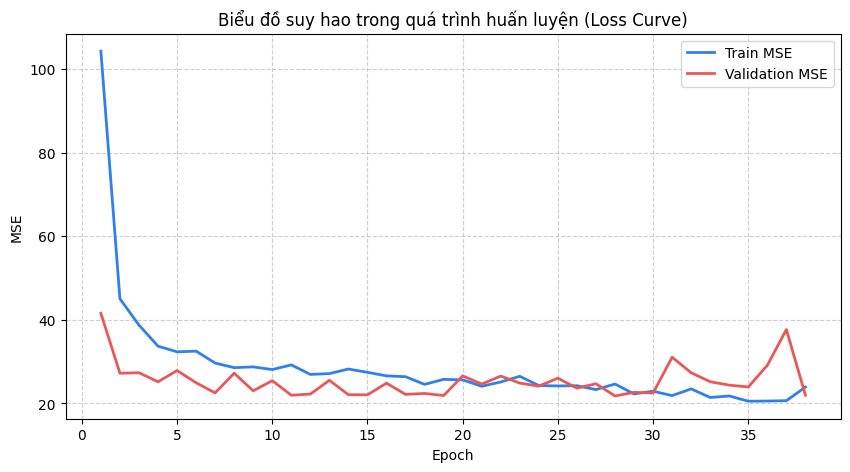

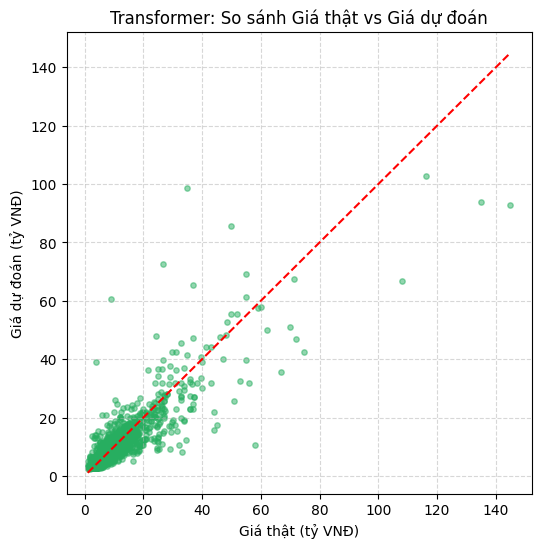

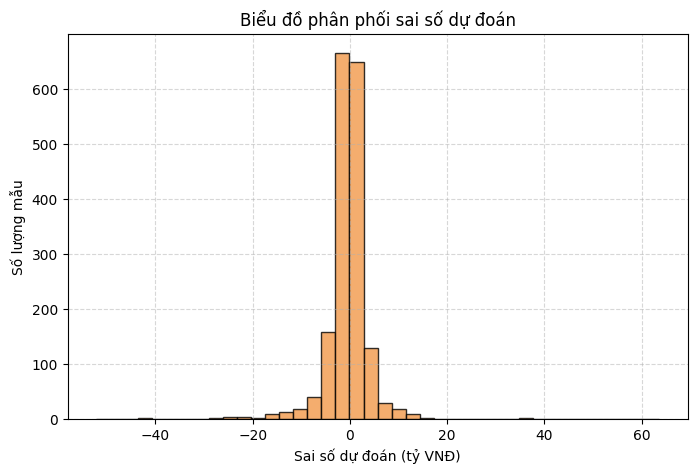

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Vẽ biểu đồ Loss
epochs_list = [item["epoch"] for item in history]
train_loss_list = [item["train_mse"] for item in history]
val_loss_list = [item["val_mse"] for item in history]

plt.figure(figsize=(10, 5))
plt.plot(epochs_list, train_loss_list, label="Train MSE", color="#2f80ed", linewidth=2)
plt.plot(epochs_list, val_loss_list, label="Validation MSE", color="#eb5757", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Biểu đồ suy hao trong quá trình huấn luyện (Loss Curve)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig(OUTPUT_DIR / "training_loss.png", dpi=150)
plt.show()

# 2. Đồ thị Scatter: Giá thật vs Giá dự đoán
plt.figure(figsize=(6, 6))
plt.scatter(test_true, test_pred, alpha=0.5, s=15, color="#27ae60")
lo = min(test_true.min(), test_pred.min())
hi = max(test_true.max(), test_pred.max())
plt.plot([lo, hi], [lo, hi], color="red", linestyle="--", linewidth=1.5)
plt.xlabel("Giá thật (tỷ VNĐ)")
plt.ylabel("Giá dự đoán (tỷ VNĐ)")
plt.title("Transformer: So sánh Giá thật vs Giá dự đoán")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig(OUTPUT_DIR / "prediction_scatter.png", dpi=150)
plt.show()

# 3. Phân phối sai số
errors = test_pred - test_true
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=40, edgecolor="black", color="#f2994a", alpha=0.8)
plt.xlabel("Sai số dự đoán (tỷ VNĐ)")
plt.ylabel("Số lượng mẫu")
plt.title("Biểu đồ phân phối sai số dự đoán")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig(OUTPUT_DIR / "error_distribution.png", dpi=150)
plt.show()

## 9. So sánh hiệu năng với mô hình XGBoost cũ


9. SO SÁNH TRANSFORMER VỚI XGBOOST


,model,RMSE,MAE,R2,MSE,MAPE
0,XGBoost,4.880900,2.484700,0.785600,nan,nan
1,Transformer,5.357600,2.675400,0.741100,28.704200,0.286900



Nhận xét tự động:
- XGBoost có R2 cao hơn Transformer: 0.7856 so với 0.7411.
- XGBoost có MAE thấp hơn Transformer: 2.4847 so với 2.6754 tỷ VNĐ.
- XGBoost có RMSE thấp hơn Transformer: 4.8809 so với 5.3576 tỷ VNĐ.


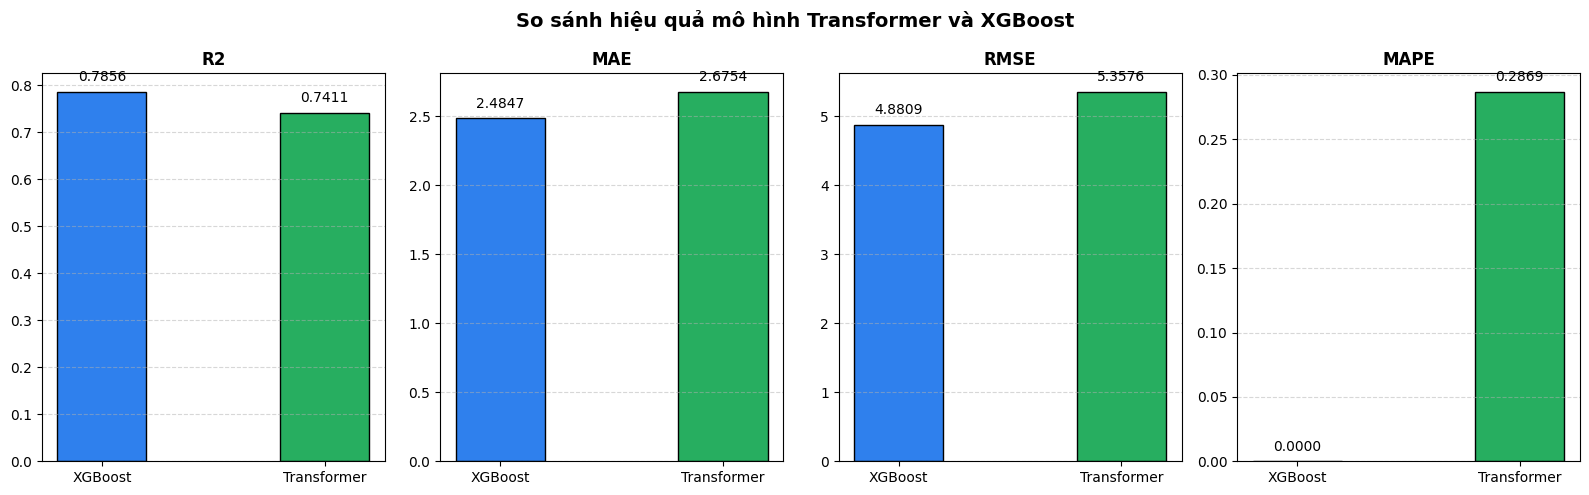

Bad pipe message: %s [b"\xac1\xbe\xc9u<\x90\xfc\x96\r~\xabsn\x06\xdc\xf8Z d5+k_\xe4\xbd\x17\xc5?\xb9|\x97\x90\xceX\xd0\xe8\xc5\xf4\x9d\xb9\x0c\x9c\xafs\x8a!\xd6O\xd9\xaa\x00$\x13\x01\x13\x02\x13\x03\xc0/\xc0+\xc00\xc0,\xc0'\xcc\xa9\xcc\xa8\xc0\t\xc0\x13\xc0\n\xc0\x14\x00\x9c\x00\x9d\x00/\x005\x01\x00\x00p\x00\x17\x00\x00\xff\x01\x00\x01\x00\x00\n\x00\x08\x00\x06\x00\x1d\x00\x17\x00\x18\x00\x0b\x00\x02\x01\x00\x00#\x00\x00\x00\r\x00\x14\x00\x12\x04\x03\x08\x04\x04\x01\x05\x03\x08\x05\x05\x01\x08\x06\x06", b'']
Bad pipe message: %s [b'']
Bad pipe message: %s [b'&\x00$\x00\x1d\x00 "\x0e\xbey\x1c\xa0\x90^\xb9\x1fB\xf3\xd0\x9a\xb4p\xceE\x86\x82\xd9f\xc2"\x1a\x12\x99\xbc\x9e\xb6\xe1*\x00-\x00\x02\x01\x01\x00+\x00\x05\x04']
Bad pipe message: %s [b'\x03\x03']
Bad pipe message: %s [b"\x01\x99\xdd2\x1c\x89\xad\xc6\xac\xaf\xc4C\xd8\xc6\xf2\r$\xd6 \xbe\xb8N\xe6\xcc=\xfc\xc9Bd9J\xe7\x96\xff\xf8@\xd3\x92\x1f_CjA\xf2\x9f(_\xb7m\xf1\x08\x00$\x13\x01\x13\x02\x13\x03\xc0/\xc0+\xc00\xc0,\xc0'\xcc\xa9\xcc

In [11]:
meta_path = PROJECT_ROOT / "models" / "model_meta.pkl"
print_section("9. SO SÁNH TRANSFORMER VỚI XGBOOST")
if meta_path.exists():
    with open(meta_path, "rb") as f:
        xgb_meta = pickle.load(f)
    xgb_metrics = xgb_meta.get("metrics", {})
    rows = [
        {"model": xgb_meta.get("best_model_name", "XGBoost"), **xgb_metrics},
        {"model": "Transformer", **test_metrics},
    ]
    comparison_df = pd.DataFrame(rows)
    comparison_df.to_csv(OUTPUT_DIR / "comparison_with_xgboost.csv", index=False)

    display_df = comparison_df.copy()
    for col in ["RMSE", "MAE", "R2", "MSE", "MAPE"]:
        if col in display_df.columns:
            display_df[col] = display_df[col].round(4)
    display_full_table(display_df)

    print("\nNhận xét tự động:")
    if "R2" in xgb_metrics:
        if xgb_metrics["R2"] > test_metrics["R2"]:
            print(f"- XGBoost có R2 cao hơn Transformer: {xgb_metrics['R2']:.4f} so với {test_metrics['R2']:.4f}.")
        else:
            print(f"- Transformer có R2 cao hơn hoặc bằng XGBoost: {test_metrics['R2']:.4f} so với {xgb_metrics['R2']:.4f}.")
    if "MAE" in xgb_metrics:
        if xgb_metrics["MAE"] < test_metrics["MAE"]:
            print(f"- XGBoost có MAE thấp hơn Transformer: {xgb_metrics['MAE']:.4f} so với {test_metrics['MAE']:.4f} tỷ VNĐ.")
        else:
            print(f"- Transformer có MAE thấp hơn hoặc bằng XGBoost: {test_metrics['MAE']:.4f} so với {xgb_metrics['MAE']:.4f} tỷ VNĐ.")
    if "RMSE" in xgb_metrics:
        if xgb_metrics["RMSE"] < test_metrics["RMSE"]:
            print(f"- XGBoost có RMSE thấp hơn Transformer: {xgb_metrics['RMSE']:.4f} so với {test_metrics['RMSE']:.4f} tỷ VNĐ.")
        else:
            print(f"- Transformer có RMSE thấp hơn hoặc bằng XGBoost: {test_metrics['RMSE']:.4f} so với {xgb_metrics['RMSE']:.4f} tỷ VNĐ.")

    labels = [row["model"] for row in rows]
    metrics_list = ["R2", "MAE", "RMSE", "MAPE"]
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    colors = ["#2f80ed", "#27ae60"]
    for ax, metric in zip(axes, metrics_list):
        values = [row.get(metric, 0) for row in rows]
        ax.bar(labels, values, color=colors, edgecolor="black", width=0.4)
        ax.set_title(metric, fontsize=12, fontweight="bold")
        ax.grid(True, axis="y", linestyle="--", alpha=0.5)
        max_value = max(values) if values else 0
        for i, val in enumerate(values):
            ax.text(i, val + (max_value * 0.02 if max_value else 0.02), f"{val:.4f}", ha="center", va="bottom", fontsize=10)

    plt.suptitle("So sánh hiệu quả mô hình Transformer và XGBoost", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "transformer_vs_xgboost.png", dpi=150)
    plt.show()
else:
    print("Không tìm thấy file model_meta.pkl của XGBoost cũ để so sánh.")
